In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  # Perform an element wise addition of two input arrays stored in a new array(list):
  sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron = []
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  for s in sums:
    if s >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    # Perform an element wise addition of two input arrays stored in a new array(list):
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for s in sums:
      if s >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.

Answer:

The limitations of MCP Neurons (McCulloch-Pitts Neurons) are:

1.  **Binary Inputs and Outputs**: MCP neurons can only handle binary inputs (0 or 1) and produce binary outputs (0 or 1). This restricts their ability to process real-valued or continuous data.
2.  **Fixed Weights and Threshold**: The weights and threshold of an MCP neuron are pre-defined and cannot be learned or adjusted from data. This means they are not adaptable and cannot learn complex patterns.
3.  **No Learning Capability**: MCP neurons do not have a learning mechanism. They are essentially hard-coded logic gates, and their behavior is entirely determined by their fixed weights and threshold.
4.  **Linear Separability**: An MCP neuron can only solve problems that are linearly separable. This means it can only classify data that can be divided into two classes by a single straight line (or hyperplane in higher dimensions). They cannot solve non-linearly separable problems like the XOR function.
5.  **Lack of Generalization**: Due to their fixed nature and inability to learn, MCP neurons cannot generalize to new, unseen data if the underlying logic is not perfectly represented by their fixed weights and threshold.
6.  **No Hidden Layers**: MCP models are single-layer networks, meaning they do not have hidden layers. This severely limits their capacity to model complex, hierarchical features in data, which is crucial for tasks like image recognition or natural language processing.

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

A single MCP neuron cannot directly implement XOR, because XOR is a non-linear problem. However, we can write its logic using if-else rules:

IF A ≠ B

    OUTPUT = 1

ELSE

    OUTPUT = 0
To actually implement XOR using MCP-style neurons, we would need multiple neurons in layers:

Compute intermediate signals:
X1 = A AND (NOT B)
X2 = (NOT A) AND B
Combine them:
OUTPUT = X1 OR X2

This multi-neuron structure can model XOR, even though a single MCP neuron cannot.

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI Sem6/Worksheet3/mnist_0_and_1.csv")  # file path

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question 1: What does the shape of X represent?

Answer:

The shape of X, (12665, 784), represents:

12665: The total number of images (samples) in the dataset that are either digit 0 or digit 1.

784: The number of features per sample. Since each image is 28x28 pixels, it is flattened into a 1D array of 784 pixels.

### Viewing the Dataset.

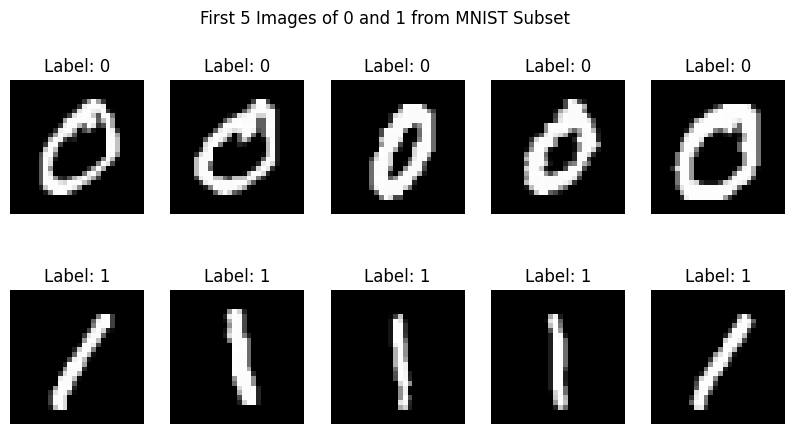

In [6]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [7]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question 3: What does the weights array represent in this context?

Answer:

In this context, the weights array represents the learned parameters of the perceptron. Each weight corresponds to a specific pixel in the input image and indicates its importance in distinguishing between the two classes (0 or 1). Together, these weights define the linear decision boundary that the perceptron uses to classify input images.

Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Answer:

Weights are initialized to zero to give the perceptron a neutral starting point, meaning it has no preference for any input feature at the beginning. During training, the perceptron updates these weights based on mistakes it makes, gradually learning which features (pixels) are important for classification. For a single-layer perceptron, zero initialization works fine because the updates quickly break any initial symmetry. In deeper networks, however, starting with all zeros can cause problems because multiple neurons may learn the same features, but this is not an issue for a single perceptron.

## Step - 3 - Make a Decision function:

In [28]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)  # Activation function (step function)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [31]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            # 1. Calculate the linear output
            z = np.dot(X[i], weights) + bias

            # 2. Apply step function
            y_hat = 1 if z >= 0 else 0

            # 3. Update weights and bias if prediction is wrong
            if y_hat != y[i]:
                update = learning_rate * (y[i] - y_hat)
                weights += update * X[i]
                bias += update
                errors += 1

        accuracy = 1 - (errors / n_samples)
        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}: Accuracy = {accuracy:.4f}")

        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Answer:

This line calculates the net input (or activation) of the perceptron for a given sample X[i]. It performs a weighted sum of the input features and adds the bias term. This value is then passed to the activation function to determine the perceptron's output.

Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

Answer:

When the perceptron makes a wrong prediction, it calculates the error as

error = true_label - predicted_label.

If the error is not zero, the perceptron updates its parameters to reduce future mistakes.

Weights update: Each weight is adjusted according to the formula

* weights = weights + learning_rate * error * X[i]

This increases or decreases the weight based on how much that input feature contributed to the error.

Bias update: The bias is adjusted as

* bias = bias + learning_rate * error

This shifts the decision boundary to help correct the misclassification.

These updates ensure that the perceptron gradually learns from its mistakes, moving the decision boundary toward correctly classifying all samples.

Question 7: Why is the final accuracy important, and what do you expect it to be?

Answer:

The final accuracy measures how well the trained perceptron classifies all the samples in the dataset. It shows the proportion of inputs that the model predicted correctly after training. High final accuracy indicates that the perceptron has successfully learned the patterns in the data and can reliably distinguish between the two classes.

For a simple dataset like distinguishing between two digits (e.g., 0 and 1), we expect the final accuracy to be close to 100% if the data is linearly separable. If the data has overlapping features or noise, the accuracy may be slightly lower.

## Training the Perceptron

In [32]:
# Re-initialize to ensure a clean start
weights = np.zeros(X.shape[1])
bias = 0

# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10)

print("The Final Accuracy is: ", accuracy)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 1/10: Accuracy = 0.9967
Epoch 2/10: Accuracy = 0.9982
Epoch 3/10: Accuracy = 0.9987
Epoch 4/10: Accuracy = 0.9987
Epoch 5/10: Accuracy = 0.9990
Epoch 6/10: Accuracy = 0.9993
Epoch 7/10: Accuracy = 0.9998
Epoch 8/10: Accuracy = 0.9995
Epoch 9/10: Accuracy = 0.9989
Epoch 10/10: Accuracy = 0.9992
The Final Accuracy is:  0.9992104224240032
The Final Accuracy is:  0.9992104224240032


## Step 5: Visualize Misclassified Images

Final Accuracy on full dataset: 0.9992


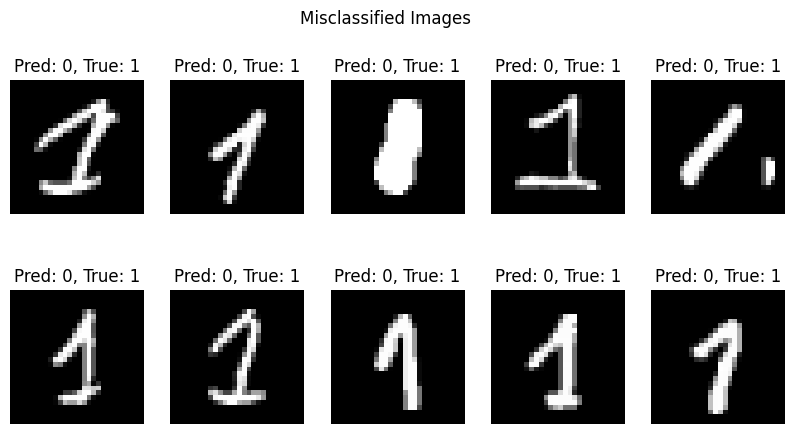

In [33]:
# Get predictions for all data points
y_pred = decision_function(X, weights, bias)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy on full dataset: {final_accuracy:.4f}")

# Find misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_to_show = min(len(misclassified_idx), 10)
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_to_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Question - 8:What does misclassified idx store, and how is it used in this code?

Answer:

misclassified_idx is a NumPy array that stores the indices of all data points from the test set (X_test) for which the perceptron's `y_pred` (predicted label) did not match the `y_test` (true label).

**How it's used in the code:**

Identification: It is generated using np.where(y_pred != y_test)[0], which finds all positions where the predicted label differs from the actual label.

Visualization: These indices are then used to select the corresponding images from X and display them. By reshaping each selected image back to 28×28 pixels, the code visualizes the misclassified digits along with their predicted and true labels. This helps in analyzing which samples the perceptron struggled with and understanding its limitations.

Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?

Answer:

If the output is "All images were correctly classified!", it means the perceptron achieved 100% accuracy. This indicates that the dataset is linearly separable, and the perceptron successfully learned a perfect decision boundary.

# Understanding Perceptron and Perceptron Learning Algorithm.

## Solving "OR" Function with Perceptron.

In [ ]:
import numpy as np

class Perceptron:
    """
    A simple Perceptron classifier for binary classification.

    Attributes:
    -----------
    weights : np.ndarray
        Array of weights including the bias term, initialized randomly.
    learning_rate : float
        The step size for weight updates.
    epochs : int
        The number of training iterations over the dataset.

    Methods:
    --------
    step_function(z)
        Activation function that returns 1 if z >= 0, else 0.

    predict(x)
        Predicts the output for a given input sample x.

    train(X, Y)
        Trains the perceptron on the given dataset (X: inputs, Y: target labels).

    Example:
    --------
    >>> X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    >>> Y = np.array([0, 1, 1, 1])  # OR function
    >>> perceptron = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
    >>> perceptron.train(X, Y)
    >>> print(perceptron.predict([1, 1]))  # Expected output: 1
    """

    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        """
        Initializes the perceptron with small random weights.

        Parameters:
        -----------
        input_size : int
            Number of input features.
        learning_rate : float, optional (default=0.1)
            Step size for weight updates.
        epochs : int, optional (default=10)
            Number of times to iterate over the dataset.
        """
        self.weights = np.random.rand(input_size + 1) * 0.2 - 0.1  # Small random weights
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step_function(self, z):
        """
        Step activation function.

        Parameters:
        -----------
        z : float
            Weighted sum of inputs and weights.

        Returns:
        --------
        int
            1 if z >= 0, else 0.
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Predicts the output for a given input sample.

        Parameters:
        -----------
        x : array-like
            Input feature vector.

        Returns:
        --------
        int
            Predicted class label (0 or 1).
        """
        x = np.insert(x, 0, 1)  # Bias term
        z = np.dot(self.weights, x)
        return self.step_function(z)

    def train(self, X, Y):
        """
        Trains the perceptron using the perceptron learning rule.

        Parameters:
        -----------
        X : np.ndarray
            Training data (each row is an input sample).
        Y : np.ndarray
            Corresponding target labels (0 or 1).

        Prints:
        -------
        Updates the weights and prints them after each epoch.
        """
        X = np.c_[np.ones(X.shape[0]), X]  # Add bias term to input
        for epoch in range(self.epochs):
            for i in range(X.shape[0]):
                z = np.dot(self.weights, X[i])
                y_pred = self.step_function(z)
                error = Y[i] - y_pred
                self.weights += self.learning_rate * error * X[i]
            print(f"Epoch {epoch+1}, Weights: {self.weights}")


In [ ]:
# Example usage with adjustable input size
learning_rate = 0.1
epochs = 10
input_size = 3

# Create training data (modify as needed for different functions and input sizes)
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1],
])

# OR function with 3 inputs
Y = np.array([0, 1, 1, 1, 1, 1, 1, 1])

# Initialize and train the perceptron
perceptron = Perceptron(input_size, learning_rate=learning_rate, epochs=epochs)
perceptron.train(X, Y)

# Test the perceptron
test_samples = X  # Use the same training samples for testing
print("\nPredictions:")
for sample in test_samples:
    print(f"Input: {sample}, Prediction: {perceptron.predict(sample)}")

Epoch 1, Weights: [0.19147444 0.01256878 0.09580089 0.06438902]
Epoch 2, Weights: [0.09147444 0.01256878 0.09580089 0.06438902]
Epoch 3, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 4, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 5, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 6, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 7, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 8, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 9, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]
Epoch 10, Weights: [-0.00852556  0.01256878  0.09580089  0.06438902]

Predictions:
Input: [0 0 0], Prediction: 0
Input: [0 0 1], Prediction: 1
Input: [0 1 0], Prediction: 1
Input: [0 1 1], Prediction: 1
Input: [1 0 0], Prediction: 1
Input: [1 0 1], Prediction: 1
Input: [1 1 0], Prediction: 1
Input: [1 1 1], Prediction: 1


## Trying for "XOR" Function.

In [ ]:
import numpy as np

class Perceptron:
    """
    A simple implementation of a Perceptron for binary classification.

    This perceptron learns a linear decision boundary using the Perceptron Learning Rule.
    It can be used to classify linearly separable datasets such as AND, OR, but not XOR.

    Attributes:
    -----------
    weights : np.ndarray
        Weight vector including the bias term, initialized randomly.
    learning_rate : float
        The step size for weight updates during training.
    epochs : int
        Number of times the entire dataset is passed through during training.

    Methods:
    --------
    step_function(z)
        Applies a step activation function (returns 1 if z >= 0, else 0).

    predict(x)
        Predicts the class label for a given input sample.

    train(X, Y)
        Trains the perceptron on a given dataset by updating weights iteratively.

    Example:
    --------
    >>> X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    >>> Y = np.array([0, 1, 1, 1])  # OR function
    >>> perceptron = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
    >>> perceptron.train(X, Y)
    >>> print(perceptron.predict([1, 1]))  # Expected output: 1
    """

    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        """
        Initializes the perceptron model.

        Parameters:
        -----------
        input_size : int
            Number of input features (excluding the bias term).
        learning_rate : float, optional (default=0.1)
            Step size for weight updates.
        epochs : int, optional (default=10)
            Number of training iterations over the dataset.
        """
        self.weights = np.random.rand(input_size + 1) * 0.2 - 0.1  # Small random weights
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step_function(self, z):
        """
        Step activation function.

        Parameters:
        -----------
        z : float
            Weighted sum of inputs and weights.

        Returns:
        --------
        int
            1 if z >= 0, else 0.
        """
        return 1 if z >= 0 else 0

    def predict(self, x):
        """
        Predicts the output for a given input sample.

        Parameters:
        -----------
        x : array-like
            Input feature vector (excluding bias).

        Returns:
        --------
        int
            Predicted class label (0 or 1).
        """
        x = np.insert(x, 0, 1)  # Insert bias term at the beginning
        z = np.dot(self.weights, x)
        return self.step_function(z)

    def train(self, X, Y):
        """
        Trains the perceptron using the perceptron learning algorithm.

        Parameters:
        -----------
        X : np.ndarray
            Training data, where each row represents an input sample.
        Y : np.ndarray
            Target labels corresponding to the input samples (0 or 1).

        Prints:
        -------
        Updates the weights and prints them after each epoch.
        """
        X = np.c_[np.ones(X.shape[0]), X]  # Add bias term to input
        for epoch in range(self.epochs):
            for i in range(X.shape[0]):
                z = np.dot(self.weights, X[i])
                y_pred = self.step_function(z)
                error = Y[i] - y_pred
                self.weights += self.learning_rate * error * X[i]
            print(f"Epoch {epoch+1}, Weights: {self.weights}")


In [ ]:
# XOR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 1, 1, 0])  # XOR target

# Initialize and train the perceptron
input_size = X.shape[1]
perceptron = Perceptron(input_size, epochs=100)  # Increased epochs for demonstration
perceptron.train(X, Y)

# Test the perceptron
print("\nXOR Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Prediction: {perceptron.predict(X[i])}, Target: {Y[i]}")


Epoch 1, Weights: [-0.07098996 -0.10287306  0.05772657]
Epoch 2, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 3, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 4, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 5, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 6, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 7, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 8, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 9, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 10, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 11, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 12, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 13, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 14, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 15, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 16, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 17, Weights: [ 0.02901004 -0.10287306  0.05772657]
Epoch 18, Weights: [ 0.02901004 -0.10287

#Task 3: Perceptron Algorithm for 3 vs 5 Classification.

## Load Dataset

Load the 'mnist_3_and_5.csv' dataset into a pandas DataFrame.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI Sem6/Worksheet3/mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Note: The dataset uses 3 and 5 as labels.
# For a binary perceptron (0/1 output), we map these to 0 and 1.
y_mapped = np.where(y == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Unique labels in original data:", np.unique(y))
print("Unique labels after mapping:", np.unique(y_mapped))

Feature matrix shape: (2741, 784)
Unique labels in original data: [3 5]
Unique labels after mapping: [0 1]


Visualize the data

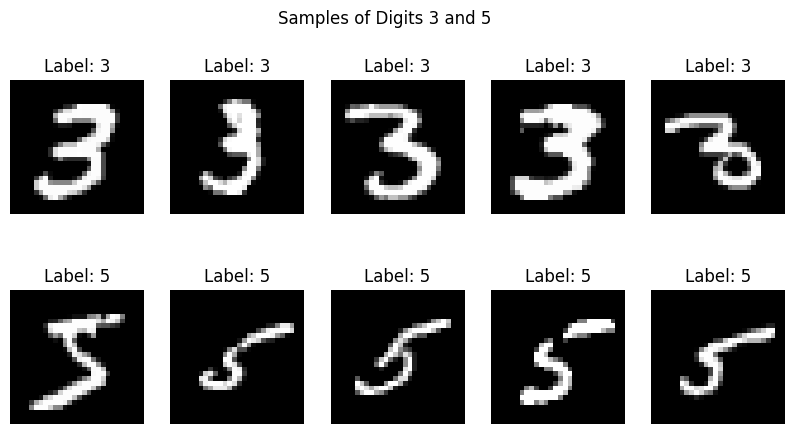

In [41]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(min(len(images_3), 5)):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")
for i in range(min(len(images_5), 5)):
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("Samples of Digits 3 and 5")
plt.show()

In [44]:
def train_perceptron(X, y, learning_rate=0.1, epochs=20):
    weights = np.zeros(X.shape[1])
    bias = 0
    n_samples = X.shape[0]

    accuracies_per_epoch = []

    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            z = np.dot(X[i], weights) + bias
            y_hat = 1 if z >= 0 else 0

            if y_hat != y[i]:
                update = learning_rate * (y[i] - y_hat)
                weights += update * X[i]
                bias += update
                errors += 1

        accuracy = 1 - (errors / n_samples)
        accuracies_per_epoch.append(accuracy)

        if (epoch + 1) % 1 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Accuracy = {accuracy:.4f}")

        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break

    return weights, bias, accuracies_per_epoch

# Train on 3 vs 5
weights, bias, accuracies_per_epoch = train_perceptron(X, y_mapped, epochs=20)

Epoch 1/20: Accuracy = 0.9157
Epoch 2/20: Accuracy = 0.9372
Epoch 3/20: Accuracy = 0.9416
Epoch 4/20: Accuracy = 0.9475
Epoch 5/20: Accuracy = 0.9489
Epoch 6/20: Accuracy = 0.9504
Epoch 7/20: Accuracy = 0.9599
Epoch 8/20: Accuracy = 0.9559
Epoch 9/20: Accuracy = 0.9540
Epoch 10/20: Accuracy = 0.9566
Epoch 11/20: Accuracy = 0.9599
Epoch 12/20: Accuracy = 0.9580
Epoch 13/20: Accuracy = 0.9657
Epoch 14/20: Accuracy = 0.9602
Epoch 15/20: Accuracy = 0.9635
Epoch 16/20: Accuracy = 0.9657
Epoch 17/20: Accuracy = 0.9606
Epoch 18/20: Accuracy = 0.9624
Epoch 19/20: Accuracy = 0.9610
Epoch 20/20: Accuracy = 0.9661


###Visualize misclassified Images


Total Misclassified: 126 out of 2741
Final Accuracy: 0.9540


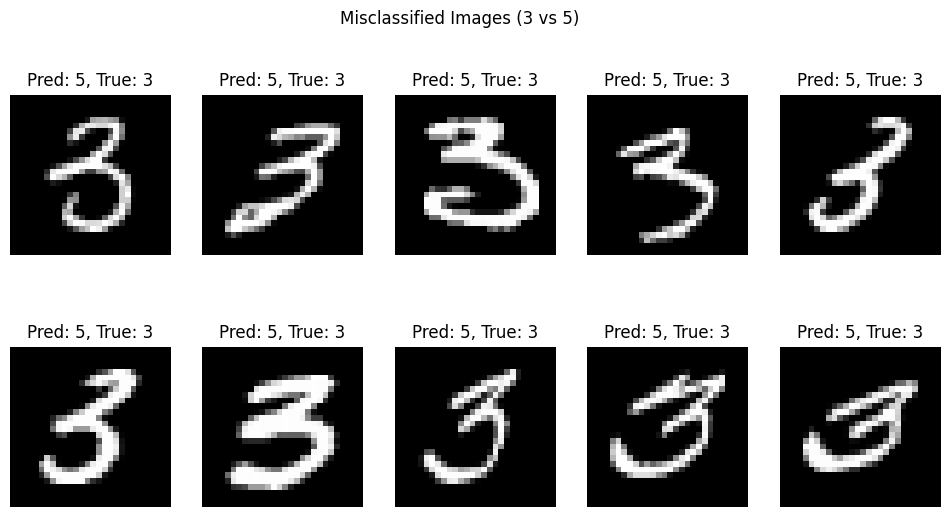

In [45]:
z_final = np.dot(X, weights) + bias
y_pred = np.where(z_final >= 0, 1, 0)
misclassified_idx = np.where(y_pred != y_mapped)[0]

print(f"Total Misclassified: {len(misclassified_idx)} out of {len(y_mapped)}")
print(f"Final Accuracy: {1 - len(misclassified_idx)/len(y_mapped):.4f}")

if len(misclassified_idx) > 0:
    n_to_show = min(len(misclassified_idx), 10)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_to_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        pred_val = 5 if y_pred[idx] == 1 else 3
        true_val = 5 if y_mapped[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_val}, True: {true_val}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

Even with an overall accuracy of about 95.4%, the perceptron struggles with certain digits that are visually ambiguous, such as 3s that look like 5s or vice versa. This shows the limitation of a simple linear classifier, which cannot handle non-linear patterns, and suggests that more advanced models like multi-layer neural networks or CNNs would perform better.